In [ ]:
import os, subprocess

# mount drive
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Download & Extract

# Konfigurasi Path
rar_source = "/content/drive/MyDrive/01.KODE/productive_state/productive_state.rar"
local_rar = "/content/productive_state.rar"
extract_path = "/content/productive_state"

# 1. Download file dari Drive ke Local Colab
if not os.path.exists(local_rar):
    print("Mengunduh dataset...")
    # Menggunakan rsync untuk memindahkan file rar
    !rsync -a --info=progress2 "{rar_source}" "{local_rar}"
else:
    print("File RAR sudah ada, melewati tahap unduh.")

# 2. Ekstraksi menggunakan unrar
if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)
    print("Mengekstrak dataset...")

    # Pastikan unrar terinstall
    !apt-get install -y unrar > /dev/null

    # Menjalankan perintah unrar
    # 'x' = extract dengan full path, '-o+' = overwrite jika ada file lama
    result = subprocess.run(['unrar', 'x', '-o+', '-idq', local_rar, extract_path])

    if result.returncode == 0:
        print("Ekstraksi selesai!")
    else:
        print("Terjadi kesalahan saat ekstraksi.")
else:
    print("Folder tujuan sudah ada, melewati tahap ekstraksi.")

Mengunduh dataset...
 34,382,380,317 100%   31.77MB/s    0:17:12 (xfr#1, to-chk=0/1)
Mengekstrak dataset...
Ekstraksi selesai!


In [ ]:
base_dataset_path = '/content/productive_state'

dataset_subdirs = {
    'train': {'images': 'images/train', 'labels': 'labels/train'},
    'val': {'images': 'images/val', 'labels': 'labels/val'},
    'test': {'images': 'images/test', 'labels': 'labels/test'}
}

print(f"Base dataset path defined as: {base_dataset_path}")
print("Dataset subdirectories defined.")

Base dataset path defined as: /content/productive_state
Dataset subdirectories defined.


In [ ]:
import os

def clean_dataset(base_path, subdirs):
    for split_name, paths in subdirs.items():
        images_path = os.path.join(base_path, paths['images'])
        labels_path = os.path.join(base_path, paths['labels'])

        if not os.path.exists(images_path):
            print(f"Warning: Image path for {split_name} does not exist: {images_path}")
            continue
        if not os.path.exists(labels_path):
            print(f"Warning: Label path for {split_name} does not exist: {labels_path}")
            continue

        image_files = {os.path.splitext(f)[0] for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))}
        label_files = {os.path.splitext(f)[0] for f in os.listdir(labels_path) if f.endswith('.txt')}

        # Identify orphaned label files
        orphaned_labels = label_files - image_files

        print(f"\nProcessing {split_name} split:")
        print(f"  Total image files: {len(image_files)}")
        print(f"  Total label files: {len(label_files)}")
        print(f"  Orphaned label files found: {len(orphaned_labels)}")

        # Delete orphaned label files
        for orphan in orphaned_labels:
            orphan_path = os.path.join(labels_path, orphan + '.txt')
            if os.path.exists(orphan_path):
                os.remove(orphan_path)
                print(f"    Deleted orphaned label file: {orphan_path}")
            else:
                print(f"    Warning: Orphaned label file {orphan_path} not found for deletion.")

        print(f"  Cleaning for {split_name} complete.")

# Call the function to clean the dataset
clean_dataset(base_dataset_path, dataset_subdirs)


Processing train split:
  Total image files: 8980
  Total label files: 8979
  Orphaned label files found: 0
  Cleaning for train complete.

Processing val split:
  Total image files: 2565
  Total label files: 2565
  Orphaned label files found: 0
  Cleaning for val complete.

Processing test split:
  Total image files: 1282
  Total label files: 1282
  Orphaned label files found: 0
  Cleaning for test complete.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.4 MB/s eta 0:00:00


# OTF preprocessing


In [ ]:
import cv2
import albumentations as A

# =========================
# EDGE ENHANCE
# =========================
class EdgeEnhance(A.ImageOnlyTransform):
    def apply(self, image, **params):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_16S, 1, 0)
        sobely = cv2.Sobel(gray, cv2.CV_16S, 0, 1)
        edge = cv2.convertScaleAbs(sobelx) + cv2.convertScaleAbs(sobely)
        edge = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
        return cv2.addWeighted(image, 0.8, edge, 0.2, 0)

# =========================
# AUGMENT RAM PIPELINE
# =========================
augment_ram = A.Compose(
    [
        A.RandomGamma(gamma_limit=(90,110), p=0.3),  # 30%
        A.Sharpen(alpha=(0.1,0.2), lightness=(0.9,1.1), p=0.2),  # 20%
        EdgeEnhance(p=0.1),  # 10%
    ],
    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


In [ ]:
from ultralytics import YOLO
import torch

# =====================================
# CALLBACK AUGMENTASI RAM
# =====================================
def on_preprocess_batch(trainer):

    batch = trainer.batch

    imgs = batch["img"]
    cls = batch["cls"]
    bboxes = batch["bboxes"]

    # Loop tiap image dalam batch
    for i in range(len(imgs)):

        image = imgs[i].permute(1,2,0).cpu().numpy()
        labels = cls[i].cpu().numpy().flatten().tolist()
        boxes = bboxes[i].cpu().numpy().tolist()

        if len(boxes) == 0:
            continue

        augmented = augment_ram(
            image=image,
            bboxes=boxes,
            class_labels=labels
        )

        new_img = augmented["image"]

        imgs[i] = (
            torch.from_numpy(new_img)
            .permute(2,0,1)
            .to(imgs.device)
        )

# Train

In [ ]:
import os
import shutil
import random

# =========================
# PATH DATASET
# =========================
base_path = '/content/productive_state'

images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

# =========================
# JUMLAH YANG DIPINDAH
# =========================
move_to_train = 631
move_to_test = 382

# =========================
# AMBIL FILE VAL
# =========================
val_images_dir = os.path.join(images_path, "val")
val_labels_dir = os.path.join(labels_path, "val")

val_images = [f for f in os.listdir(val_images_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

random.seed(42)   # seed tetap
random.shuffle(val_images)

# Split file
train_files = val_images[:move_to_train]
test_files = val_images[move_to_train:move_to_train + move_to_test]

print(f"Move to train: {len(train_files)}")
print(f"Move to test: {len(test_files)}")

# =========================
# FUNCTION PINDAH FILE + LABEL
# =========================
def move_files(file_list, target_split):
    for file in file_list:
        name = os.path.splitext(file)[0]

        src_img = os.path.join(val_images_dir, file)
        dst_img = os.path.join(images_path, target_split, file)

        src_lbl = os.path.join(val_labels_dir, name + ".txt")
        dst_lbl = os.path.join(labels_path, target_split, name + ".txt")

        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)

        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)

# =========================
# EXECUTE
# =========================
move_files(train_files, "train")
move_files(test_files, "test")

print("Done. Dataset sekarang sudah mendekati 70:20:10.")

Move to train: 631
Move to test: 382
Done. Dataset sekarang sudah mendekati 70:20:10.


In [ ]:
import os

base_dataset_path = '/content/productive_state'
dataset_subdirs = {
    'train': {'labels': 'labels/train'},
    'val': {'labels': 'labels/val'},
    'test': {'labels': 'labels/test'}
}

# Class IDs to manage
UNKNOWN_CLASS_ID = 2
FOREIGN_OBJECT_CLASS_ID_OLD = 3
FOREIGN_OBJECT_CLASS_ID_NEW = 2

print("Starting label file processing...")

for split_name, paths in dataset_subdirs.items():
    labels_path = os.path.join(base_dataset_path, paths['labels'])

    if not os.path.exists(labels_path):
        print(f"Warning: Label path for {split_name} does not exist: {labels_path}")
        continue

    print(f"\nProcessing labels for {split_name} split in {labels_path}...")
    for label_file in os.listdir(labels_path):
        if not label_file.endswith('.txt'):
            continue

        full_label_path = os.path.join(labels_path, label_file)
        updated_lines = []

        with open(full_label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue

                class_id = int(float(parts[0])) # Convert to float first, then int

                if class_id == UNKNOWN_CLASS_ID:
                    # Skip 'unknown' class
                    continue
                elif class_id == FOREIGN_OBJECT_CLASS_ID_OLD:
                    # Remap 'foreign_object' from 3 to 2
                    parts[0] = str(FOREIGN_OBJECT_CLASS_ID_NEW)
                    updated_lines.append(' '.join(parts) + '\n')
                else:
                    # Keep other classes as they are
                    updated_lines.append(line)

        # Overwrite the original file with updated labels
        with open(full_label_path, 'w') as f:
            f.writelines(updated_lines)

    print(f"  {split_name} labels processed.")

print("\n✅ Label files processed successfully: 'unknown' class removed and 'foreign_object' class remapped.")


Starting label file processing...

Processing labels for train split in /content/productive_state/labels/train...
  train labels processed.

Processing labels for val split in /content/productive_state/labels/val...
  val labels processed.

Processing labels for test split in /content/productive_state/labels/test...
  test labels processed.

✅ Label files processed successfully: 'unknown' class removed and 'foreign_object' class remapped.


In [ ]:
import yaml

# Tentukan path dataset
dataset_path = "/content/productive_state"

# Konfigurasi data.yaml (updated to remove 'unknown' and remap 'foreign_object')
data_yaml_content = '''
path: "/content/productive_state"
train: images/train
val: images/val
test: images/test

nc: 3  # Reduced from 4 to 3 (coal, gangue, foreign_object)
names:
  0: coal
  1: gangue
  2: foreign_object # Remapped from class 3 to class 2
'''
# Simpan file yaml

with open("/content/productive_state/data.yaml", "w") as f:
    f.write(data_yaml_content)

print(f"✅ File data.yaml berhasil dibuat di: {dataset_path}")

✅ File data.yaml berhasil dibuat di: /content/productive_state


In [ ]:
from ultralytics import YOLO

# 1. Load model pre-trained (Pilih 'n' untuk kecepatan, atau 's' untuk akurasi sedikit lebih baik)
model = YOLO('yolo11n.pt')


# model.add_callback("on_preprocess_batch", on_preprocess_batch)

# 2. Mulai Training
results = model.train(
    data= "/content/productive_state/data.yaml",      # Path ke file yaml tadi
    epochs=150,
    imgsz=640,
    batch=64,
    lr0 = 0.001,
    optimizer = 'AdamW',
    #cache='ram',
    amp=True,
    workers=12,
    device=0,
    project='/content/drive/MyDrive/01.KODE/productive_state_final/runs/Final', # Simpan ke Drive agar aman
    verbose=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/productive_state/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, pe

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive


     33/150        19G      1.038     0.5081     0.9282       3746        640: 21% ━━╸───────── 30/141 1.5it/s 19.4s<1:12

    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


     33/150      19.1G      1.038     0.5084     0.9271       1365        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:12
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.1it/s 19.1s
                   all       2565      94379      0.824      0.754      0.817      0.559

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/150      12.6G      1.036     0.5073     0.9254       1195        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:10
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.1it/s 18.6s
                   all       2565      94379      0.852      0.757      0.838      0.572

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/150      18.8G       1.03     0.5044     0.9253       3665        640: 94% ━━━━━━━━━━━─ 132/141 1.8it/s 2:04<4.9s

...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


     49/150      16.2G     0.9964     0.4781     0.9163       1053        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:12
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.2it/s 17.9s
                   all       2565      94379      0.841      0.849      0.865      0.617

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/150      18.1G     0.9908     0.4762     0.9138       1254        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.1it/s 18.8s
                   all       2565      94379      0.862      0.832      0.853      0.597

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/150      13.9G     0.9895     0.4724     0.9138       1080        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:06
                 Class     Images  Instances      Box(

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

     52/150        21G     0.9878     0.4755      0.914       1512        640: 100% ━━━━━━━━━━━━ 141/141 1.1it/s 2:07
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.2it/s 18.0s
                   all       2565      94379      0.876      0.842      0.878      0.623

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/150      16.6G     0.9727     0.4622     0.9104       4087        640: 32% ━━━╸──────── 45/141 3.7it/s 40.8s<26.0s


KeyboardInterrupt: 

# buat lanjut training dari last epoch

In [ ]:
from ultralytics import YOLO
from pathlib import Path

# Paths
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/01.KODE/productive_state_final"
LAST_PT = f"{DRIVE_PROJECT_DIR}/runs/Final/train10/weights/last.pt"   # path last.pt

# 1. Load model pre-trained (Pilih 'n' untuk kecepatan, atau 's' untuk akurasi sedikit lebih baik)
model = YOLO(LAST_PT)


# 2. Mulai Training
results = model.train(
    data= "/content/productive_state/data.yaml",      # Path ke file yaml tadi
    epochs=150,
    imgsz=640,
    batch=64,
    lr0 = 0.001,
    optimizer = 'AdamW',
    #cache='ram',
    amp=True,
    workers=12,
    device=0,
    resume=True,
    project='/content/drive/MyDrive/01.KODE/productive_state_final/runs/Final/train10', # Simpan ke Drive agar aman
    verbose=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/productive_state/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/01.KODE/productive_state_final/runs/Final/train10/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, op

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^

    139/150      16.7G      0.828     0.4052     0.8791       3613        640: 3% ──────────── 4/141 1.0s/it 3.7s<2:22

^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


    139/150      16.7G     0.8277     0.4084       0.88       3604        640: 6% ╸─────────── 8/141 1.1it/s 7.2s<2:01

...

    145/150      14.9G     0.7433     0.3662     0.8721       2010        640: 28% ━━━───────── 39/141 1.5it/s 25.8s<1:07

   ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


    145/150      14.9G     0.7381     0.3611     0.8691        683        640: 100% ━━━━━━━━━━━━ 141/141 1.4it/s 1:41
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.0s/it 21.2s


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e17d5dcc720>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

                   all       2565      94379      0.881       0.89      0.894      0.653

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    146/150      14.3G     0.7379     0.3601     0.8686        695        640: 100% ━━━━━━━━━━━━ 141/141 1.8it/s 1:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.8s/it 37.1s
                   all       2565      94379      0.881       0.89      0.894      0.653

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    147/150      14.6G     0.7364     0.3605     0.8694        659        640: 100% ━━━━━━━━━━━━ 141/141 1.8it/s 1:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.5s/it 31.8s
                   all       2565      94379      0.881       0.89      0.894      0.653

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    

# grafik

Graph saved to /content/drive/MyDrive/01.KODE/productive_state_final/runs/Final/train6/metrics_plot.png


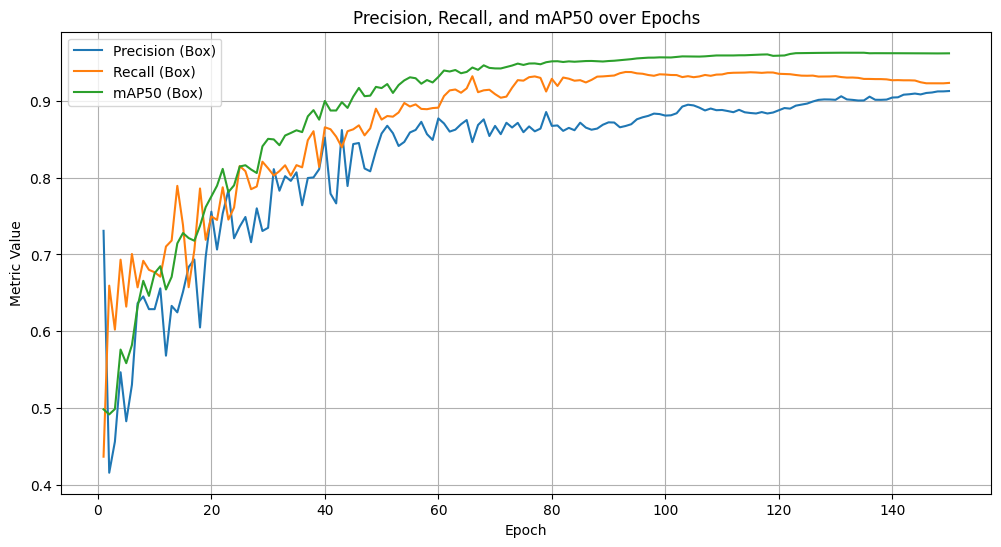

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


RUN_PATH = '/content/drive/MyDrive/01.KODE/productive_state_final/runs/Final/train6'
RESULTS_FILE = os.path.join(RUN_PATH, 'results.csv')

if os.path.exists(RESULTS_FILE):
    # Load the results CSV, skipping the first row which usually contains headers with comments
    df = pd.read_csv(RESULTS_FILE)

    # The column names might vary slightly, but they typically include 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)'
    # Let's inspect the columns to be sure
    # print(df.columns)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision (Box)')
    plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall (Box)')
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (Box)')

    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Precision, Recall, and mAP50 over Epochs')
    plt.legend()
    plt.grid(True)

    # Save the plot
    plt.savefig(os.path.join(RUN_PATH, 'metrics_plot.png'))
    print(f"Graph saved to {os.path.join(RUN_PATH, 'metrics_plot.png')}")
    plt.show() # Display the plot as well
else:
    print(f"Error: results.csv not found at {RESULTS_FILE}")
    print("Please ensure the training has completed successfully and check the path.")